# Mall Customer Segmentation using KMeans (with Gender Included)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the dataset
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Convert 'Genre' (Gender) to numeric
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

In [4]:
# Feature selection including Gender
X = df[['Genre', 'Annual Income (k$)', 'Spending Score (1-100)']]

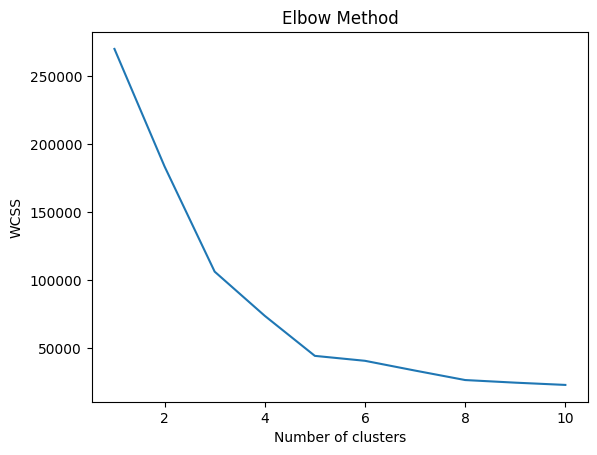

In [5]:
# Elbow method to find optimal k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [6]:
# Apply KMeans with k=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
df['Cluster'] = y_kmeans

In [7]:
# Assign segment names
segment_map = {
    0: 'Careful Rich',
    1: 'Young Spenders',
    2: 'Premium Shoppers',
    3: 'Silent Seniors',
    4: 'Value Seekers'
}
df['Segment'] = df['Cluster'].map(segment_map)

In [8]:
# View sample output
df[['CustomerID', 'Genre', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Segment']].head(10)

,CustomerID,Genre,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,0,15,39,4,Value Seekers
1,2,0,15,81,2,Premium Shoppers
2,3,1,16,6,4,Value Seekers
3,4,1,16,77,2,Premium Shoppers
4,5,1,17,40,4,Value Seekers
5,6,1,17,76,2,Premium Shoppers
6,7,1,18,6,4,Value Seekers
7,8,1,18,94,2,Premium Shoppers
8,9,0,19,3,4,Value Seekers
9,10,1,19,72,2,Premium Shoppers


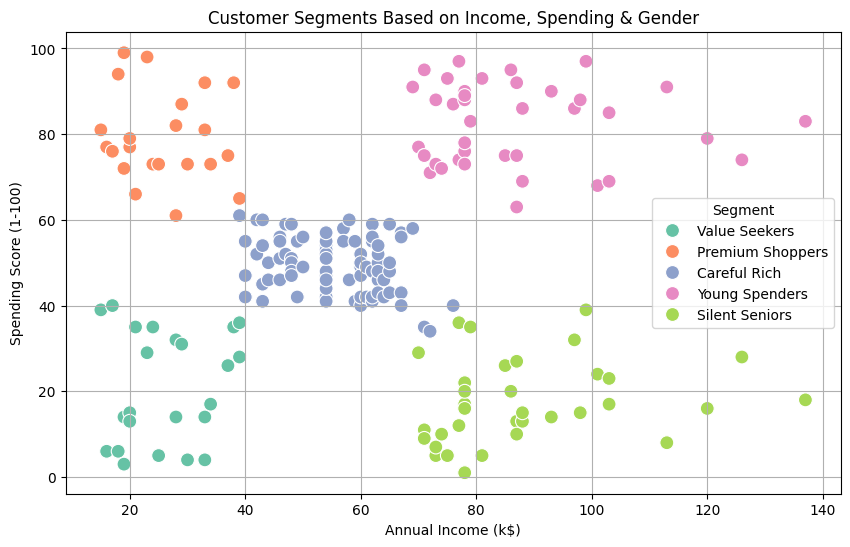

In [9]:
# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Segment', data=df, palette='Set2', s=100)
plt.title('Customer Segments Based on Income, Spending & Gender')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Segment')
plt.grid(True)
plt.show()